<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels


*   create a column for the class
*   Standardize the data
*   Split into training data and test data

*   Classification Trees used (Random Tree & XGBoost)

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


We will import the following libraries for the lab


In [1]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

This function is to plot the confusion matrix.


In [2]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, cmap="Reds"); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['Did not land', 'Land']); ax.yaxis.set_ticklabels(['Did not land', 'Landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [3]:

URL1 = "dataset_part_2.csv"
data = pd.read_csv(URL1)

In [4]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [5]:
URL2 = 'dataset_part_3.csv'
X = pd.read_csv(URL2)

In [6]:
X.head(100)

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15400.000000,6.0,1.0,1.0,1.0,5.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,89.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [7]:
Y = data['Class'].to_numpy()
Y[0:50]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1])

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [8]:
# students get this 
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


## TASK  3


<code>X_train, X_test, Y_train, Y_test</code>


In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

we can see we only have 18 test samples.


In [10]:
Y_test.shape

(18,)


🔑 Advantages of ML Pipelines

1. Automation & Efficiency
Pipelines automate repetitive tasks like data cleaning, feature engineering, and model training.

This saves time and reduces manual intervention, especially when retraining models with new data.

2. Consistency & Reproducibility
Every run follows the same sequence of steps, ensuring results are reproducible.

This is critical in production environments where models must behave predictably.

3. Error Reduction
By standardizing workflows, pipelines reduce the risk of mistakes (e.g., forgetting to scale features before training).

They enforce best practices across preprocessing, training, and evaluation.

4. Scalability
Pipelines make it easier to scale ML projects from small experiments to large production systems.

They can handle real-time data ingestion and retraining without manual reconfiguration.

5. Collaboration & Transparency
A pipeline provides a clear structure that teams can follow, making projects easier to share and maintain.

Each stage (data collection, preprocessing, training, evaluation, deployment) is documented and traceable

Test accuracy: 0.8333333333333334
Best parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy (CV best score): 0.8476190476190476
CV scores: [0.8        0.86666667 0.92857143 0.78571429 0.78571429]
Mean CV accuracy: 0.8333333333333334
Confusion Matrix:
 [[ 3  3]
 [ 0 12]]


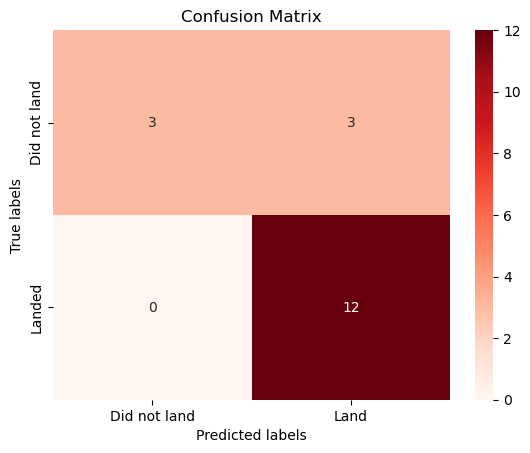

ROC SCORE: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



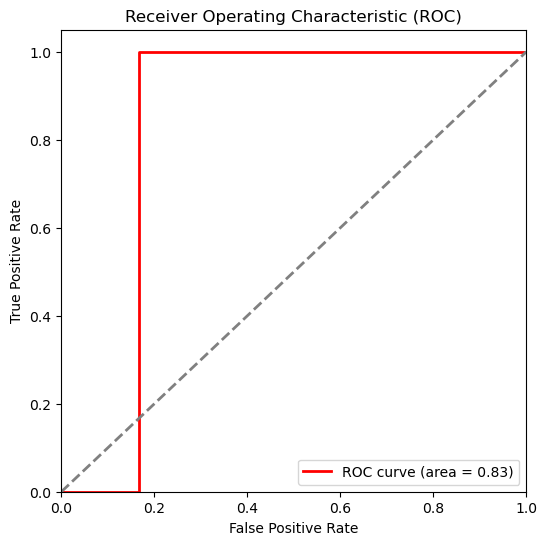

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay, auc, roc_curve

# Random Forest Classifier
parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt'],  # could also add 'log2'
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
rf_cv = GridSearchCV(rf, parameters, cv=5)

# Pipeline with tuned Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', rf_cv)
])

# Fit pipeline
pipeline.fit(X_train, Y_train)

# Evaluate on test set
print("Test accuracy:", pipeline.score(X_test, Y_test))

# Best parameters from GridSearchCV
print("Best parameters:", rf_cv.best_params_)
print("Accuracy (CV best score):", rf_cv.best_score_)

# Cross-validation scores
cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='accuracy')
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


# Confusion matrix
yhat = pipeline.predict(X_test)
cm = confusion_matrix(Y_test, yhat)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plot_confusion_matrix(Y_test,yhat)

# ROC and classification report
yhat_proba = pipeline.predict_proba(X_test)[:, 1]
print("ROC SCORE:", roc_auc_score(Y_test, yhat_proba))
print(classification_report(Y_test, yhat))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_test, yhat_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='red', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()






Test accuracy: 0.8333333333333334
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
accuracy : 0.8609523809523809
CV scores: [0.8        0.86666667 0.92857143 0.64285714 0.85714286]
Mean CV accuracy: 0.819047619047619
Confusion Matrix:
 [[ 3  3]
 [ 0 12]]


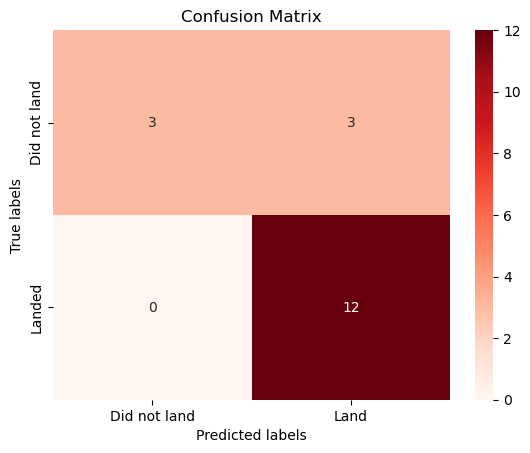

ROC SCORE: 0.888888888888889
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



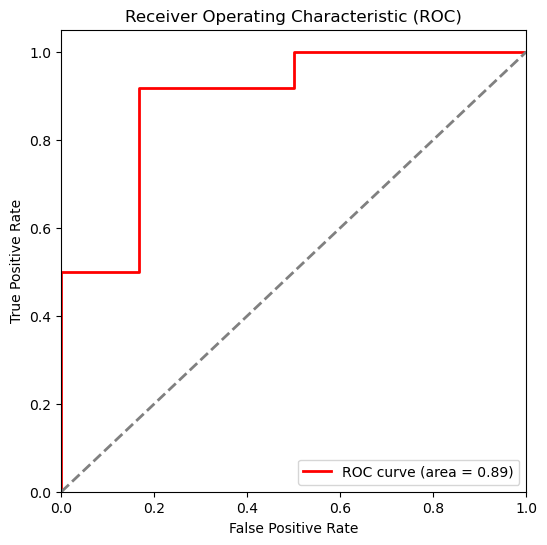

In [11]:

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, auc, roc_curve

# Parameter grid
parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

# Base model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_cv = GridSearchCV(xgb, parameters, cv=5)

# Pipeline with scaler + tuned XGBoost
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb_cv)
])

# Fit pipeline
pipeline.fit(X_train, Y_train)

# Evaluate on test set
print("Test accuracy:", pipeline.score(X_test, Y_test))

# Best parameters from GridSearchCV
print("Best parameters:", xgb_cv.best_params_)
print("accuracy :",xgb_cv.best_score_)

# Cross-validation scores
cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='accuracy')
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Confusion matrix
yhat = pipeline.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(Y_test, yhat))

# Plot the Confusion Matrix
plot_confusion_matrix(Y_test,yhat)

# ROC and classification report
yhat_proba = pipeline.predict_proba(X_test)[:, 1]
print("ROC SCORE:", roc_auc_score(Y_test, yhat_proba))
print(classification_report(Y_test, yhat))

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_test, yhat_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='red', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()





## Overview

Comparing the two models: Random Forest vs XGBoost:

Between the two models the accuracy for the XGboost classifier was better than Random Forrset

Test Accuracy:

* XGBoost- 0.86
* Random Forrest - 0.84

Overal ROC SCORE:

* XGBoost - 0.88
* Random Forrest - 0.83

Prediction Results from Confuction Matrix

True Label: Did not land, Predicted: Did not land -> 3. Model correctly identified 3 boosters that did not land.

True Label: Did not land, Predicted: land -> 3. Model incorrectly predicted 3 boosters would land when they actually did not (false positive)

True Label: Landed, Predicted: Did not land -> 0. Model never missed a booster that actually landed (no false negatives)

True Label: Landed, Predicted: Land -> 12. Model correctly identified 12 boosters that landed


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
